In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("housepricedata.csv")

In [3]:
df.head()

,LotArea,OverallQual,OverallCond,TotalBsmtSF,FullBath,HalfBath,BedroomAbvGr,TotRmsAbvGrd,Fireplaces,GarageArea,AboveMedianPrice
0,8450,7,5,856,2,1,3,8,0,548,1
1,9600,6,8,1262,2,0,3,6,1,460,1
2,11250,7,5,920,2,1,3,6,1,608,1
3,9550,7,5,756,1,0,3,7,1,642,0
4,14260,8,5,1145,2,1,4,9,1,836,1


In [4]:
df.isnull().sum()

LotArea             0
OverallQual         0
OverallCond         0
TotalBsmtSF         0
FullBath            0
HalfBath            0
BedroomAbvGr        0
TotRmsAbvGrd        0
Fireplaces          0
GarageArea          0
AboveMedianPrice    0
dtype: int64

In [11]:
# Features and target
x = df.iloc[:, 0:10]      # all rows, first 10 columns
y = df.iloc[:, 10]        # all rows, target column

In [12]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

In [13]:
x_scale = scaler.fit_transform(x)

In [14]:
from sklearn.model_selection import train_test_split
x_trin, x_test, y_train , y_test = train_test_split(x_scale, y, test_size = 0.3, random_state = 1)

In [16]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [17]:
model = Sequential()

In [18]:
# input layer
input_layers = Dense(20 , input_shape = (10,))

In [19]:
model.add(input_layers)

In [20]:
# hidden layers
hidden_layer1 = Dense(20, activation = 'relu')

In [21]:
hidden_layer2 = Dense(20, activation = 'relu')

In [22]:
model.add(hidden_layer1)

In [23]:
model.add(hidden_layer2)

In [24]:
# output layers
output_layer = Dense(1, activation='sigmoid')

In [25]:
model.add(output_layer)

In [30]:
# compile model
model.compile(loss = 'binary_crossentropy' , optimizer = 'sgd' , metrics = ['accuracy'])

In [31]:
model.fit(x_trin, y_train , epochs = 100 ,batch_size = 10)

Epoch 1/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.5127 - loss: 0.6754
Epoch 2/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5930 - loss: 0.6552
Epoch 3/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7221 - loss: 0.6341
Epoch 4/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7710 - loss: 0.6086
Epoch 5/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.7691 - loss: 0.5781
Epoch 6/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8219 - loss: 0.5457
Epoch 7/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8317 - loss: 0.5112
Epoch 8/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8405 - loss: 0.4777
Epoch 9/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8542 - loss: 0.4459
Epoch 10/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8571 - loss: 0.4170
Epoch 11/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8591 - loss: 0.3938
Epoch 12/100
103/103 ━━━━━━━━━━━━━━━━━━━

In [33]:
val_loss ,val_acc = model.evaluate(x_test, y_test)

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8927 - loss: 0.2217


In [34]:
val_loss

0.2216700315475464

In [35]:
val_acc

0.8926940560340881

In [36]:
lst = [[14260 , 8,5,1145,2,1,4,9,1,836]]

In [37]:
scaled_data = scaler.transform(lst)

In [38]:
result = model.predict(scaled_data)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step


In [39]:
if result >= 0.5:
    print('1')
else:
    print("0")

1


In [40]:
history = model.fit(x_trin, y_train, epochs=100, batch_size=10, validation_data=(x_test, y_test))

Epoch 1/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.8953 - loss: 0.2591 - val_accuracy: 0.8767 - val_loss: 0.3124
Epoch 2/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.8855 - loss: 0.2631 - val_accuracy: 0.8927 - val_loss: 0.2361
Epoch 3/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.8924 - loss: 0.2592 - val_accuracy: 0.9087 - val_loss: 0.2259
Epoch 4/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9002 - loss: 0.2601 - val_accuracy: 0.9041 - val_loss: 0.2279
Epoch 5/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8894 - loss: 0.2577 - val_accuracy: 0.8973 - val_loss: 0.2315
Epoch 6/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.8924 - loss: 0.2604 - val_accuracy: 0.8950 - val_loss: 0.2250
Epoch 7/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.9002 - loss: 0.2498 - val_accuracy: 0.8881 - val_loss: 0.2454
Epoch 8/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8875 - loss: 0.2551 - v

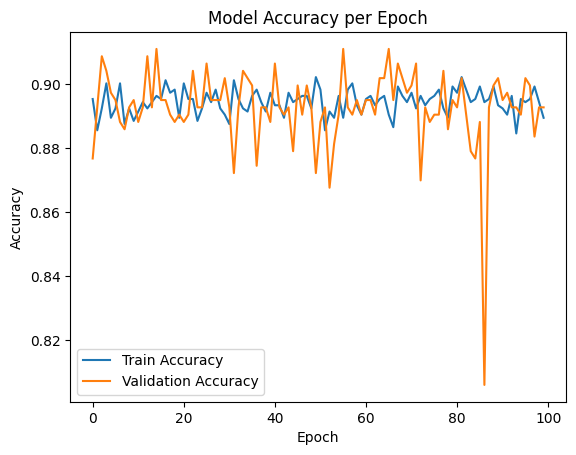

In [41]:
# Training accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')

# Validation accuracy
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Model Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

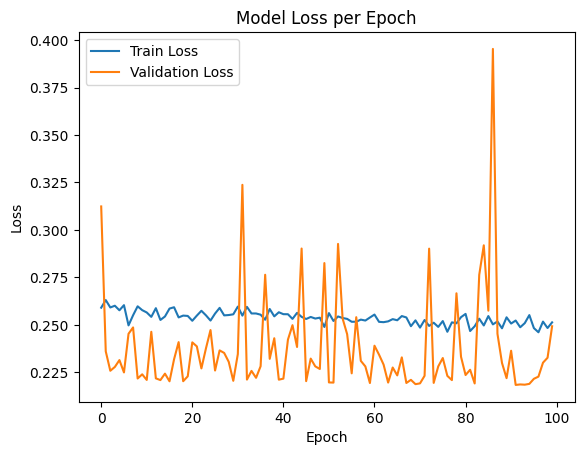

In [42]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Model Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [43]:
# Predict probabilities
y_pred_probabilities = model.predict(x_test)

# Convert to 0 or 1
y_pred = (y_pred_probabilities >= 0.5).astype(int)

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


In [44]:
y_pred = y_pred.flatten()

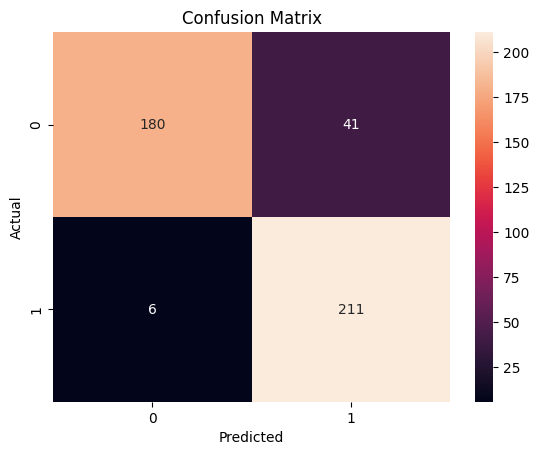

In [45]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(conf_matrix, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [46]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.81      0.88       221
           1       0.84      0.97      0.90       217

    accuracy                           0.89       438
   macro avg       0.90      0.89      0.89       438
weighted avg       0.90      0.89      0.89       438



In [47]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.8926940639269406
Precision: 0.8373015873015873
Recall: 0.9723502304147466
F1 Score: 0.8997867803837953


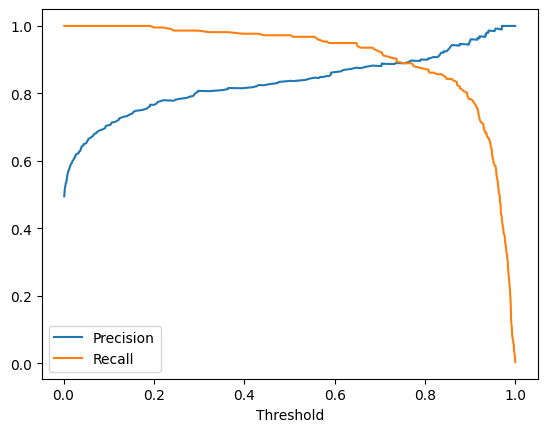

In [48]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_pred_probabilities)

plt.figure()
plt.plot(thresholds, precision[:-1], label="Precision")
plt.plot(thresholds, recall[:-1], label="Recall")
plt.xlabel("Threshold")
plt.legend()
plt.show()

In [49]:
from sklearn.metrics import f1_score
import numpy as np

thresholds = np.arange(0.1, 0.95, 0.01)
best_f1 = 0
best_threshold = 0

for t in thresholds:
    y_pred_temp = (y_pred_probabilities >= t).astype(int)
    score = f1_score(y_test, y_pred_temp)
    
    if score > best_f1:
        best_f1 = score
        best_threshold = t

print("Best Threshold:", best_threshold)
print("Best F1:", best_f1)

Best Threshold: 0.6399999999999997
Best F1: 0.911504424778761


In [50]:
optimal_threshold = 0.64

y_pred_final = (y_pred_probabilities >= optimal_threshold).astype(int)
y_pred_final = y_pred_final.flatten()

In [51]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred_final))

cm = confusion_matrix(y_test, y_pred_final)
print(cm)

              precision    recall  f1-score   support

           0       0.95      0.87      0.91       221
           1       0.88      0.95      0.91       217

    accuracy                           0.91       438
   macro avg       0.91      0.91      0.91       438
weighted avg       0.91      0.91      0.91       438

[[192  29]
 [ 11 206]]


In [53]:
# Step 1: define new sample
new_data = [[14260, 8, 5, 1145, 2, 1, 4, 9, 1, 836]]

# Step 2: scale
scaled_data = scaler.transform(new_data)

# Step 3: probability
prob = model.predict(scaled_data)

# Step 4: apply best threshold
prediction = (prob >= 0.64).astype(int)

print("Probability:", prob[0][0])
print("Prediction:", prediction[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
Probability: 0.9907621
Prediction: 1


In [54]:
model.save("house_price_model.h5")

In [55]:
import joblib

joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [56]:
threshold = 0.64
joblib.dump(threshold, "threshold.pkl")

['threshold.pkl']

In [57]:
model.save("house_price_model.keras")

In [58]:
from tensorflow.keras.models import load_model
import joblib

# Load model
model = load_model("house_price_model.h5")

# Load scaler
scaler = joblib.load("scaler.pkl")

# Load threshold
threshold = joblib.load("threshold.pkl")

In [59]:
new_data = [[14260, 8, 5, 1145, 2, 1, 4, 9, 1, 836]]

scaled_data = scaler.transform(new_data)

prob = model.predict(scaled_data)

prediction = (prob >= threshold).astype(int)

print("Probability:", prob[0][0])
print("Prediction:", prediction[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step
Probability: 0.9907621
Prediction: 1
